In [1]:
# Assignment 4 – Task A
# Deep Reinforcement Learning
# CartPole with DQN | LunarLander with PPO

In [2]:
!pip install stable-baselines3[extra] gymnasium[classic-control,box2d] -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 6.8 MB/s eta 0:00:00


In [3]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import gymnasium as gym

from stable_baselines3 import DQN, PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor

warnings.filterwarnings("ignore")

SEED = 42
COLORS = plt.cm.tab10.colors

print("Imports done.")

Imports done.


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [4]:
#Callback to track rewards and loss during training

class TrainingCallback(BaseCallback):

    def __init__(self):
        super().__init__(verbose=0)
        self.ep_rewards = []
        self.losses = []
        self._ep_reward = 0.0

    def _on_step(self) -> bool:
        # add up rewards until the episode ends
        self._ep_reward += self.locals.get("rewards", [0])[0]

        if self.locals.get("dones", [False])[0]:
            self.ep_rewards.append(self._ep_reward)
            self._ep_reward = 0.0

        # pull the latest loss value out of SB3's internal logger
        log = getattr(getattr(self.model, "logger", None), "name_to_value", {})
        for key in ("train/loss", "train/value_loss", "train/policy_gradient_loss"):
            if key in log:
                self.losses.append(log[key])
                break
        return True

def smooth(arr, w=25):
    # moving average to make curves easier to read
    arr = np.array(arr)
    if len(arr) < w:
        return arr
    return np.convolve(arr, np.ones(w) / w, mode="valid")

print("Callback and helpers ready.")

Callback and helpers ready.


In [5]:
#Task 2: Train a DQN agent on CartPole-v1

# CartPole: agent pushes a cart left or right to keep the pole upright
# Discrete action space (0 = push left, 1 = push right) so DQN fits well

In [6]:
print("Training DQN on CartPole-v1")

env_cartpole = Monitor(gym.make("CartPole-v1"))

dqn_agent = DQN(
    "MlpPolicy",
    env_cartpole,
    learning_rate = 1e-3,
    buffer_size = 50_000,   # size of the replay buffer
    learning_starts = 1_000,    # steps before training begins (replay start size)
    batch_size = 64,
    gamma = 0.99,     # discount factor
    exploration_fraction = 0.2,      # fraction of training spent exploring
    exploration_final_eps = 0.02,     # minimum epsilon after decay
    train_freq = 4,        # update the network every 4 steps
    target_update_interval  = 500,      # how often to sync target network
    policy_kwargs  = dict(net_arch=[64, 64]),  # 2 hidden layers, 64 nodes each
    verbose = 0,
    seed = SEED,
)

cb_baseline = TrainingCallback()
dqn_agent.learn(total_timesteps=100_000, callback=cb_baseline, progress_bar=True)
env_cartpole.close()

print(f"\nTotal episodes: {len(cb_baseline.ep_rewards)}")
print(f"Last-50 avg reward: {np.mean(cb_baseline.ep_rewards[-50:]):.1f}  (max possible = 500)")

Training DQN on CartPole-v1


Output()


Total episodes: 1314
Last-50 avg reward: 79.7  (max possible = 500)


In [19]:
#Task 3: Train a PPO agent on LunarLander-v3

# LunarLander: agent fires thrusters to land between two flags
# Still discrete (4 actions: nothing, left, main, right engine)
# PPO chosen over DQN here because:
# - rewards are sparse and delayed (only big signal on landing/crashing)
# - PPO's advantage estimation (GAE) handles this more stably
# - on-policy updates avoid stale experience issues from the replay buffer

In [9]:
print("Training PPO on LunarLander-v3")

env_lunar = Monitor(gym.make("LunarLander-v3"))

ppo_agent = PPO(
    "MlpPolicy",
    env_lunar,
    learning_rate = 3e-4,
    n_steps  = 2048,     # steps collected per update
    batch_size = 64,
    n_epochs = 10,       # passes over each batch
    gamma = 0.999,
    gae_lambda = 0.98,     # GAE smoothing factor
    clip_range = 0.2,      # PPO clipping parameter
    ent_coef = 0.01,     # entropy bonus to encourage exploration
    policy_kwargs = dict(net_arch=[dict(pi=[256, 256], vf=[256, 256])]),
    verbose = 0,
    seed = SEED,
)

cb_ppo = TrainingCallback()
ppo_agent.learn(total_timesteps=400_000, callback=cb_ppo, progress_bar=True)
env_lunar.close()

print(f"\nTotal episodes : {len(cb_ppo.ep_rewards)}")
print(f"Last-50 avg reward: {np.mean(cb_ppo.ep_rewards[-50:]):.1f}  (solved threshold = 200)")

Output()

Training PPO on LunarLander-v3



Total episodes : 1146
Last-50 avg reward: 225.7  (solved threshold = 200)


In [18]:
#Task 4: Ablation study — modify hyperparameters and compare performance

# We test one change at a time vs the baseline so we can isolate
# the effect of each parameter on training

In [10]:
ablation_configs = [
    # (label, net_arch, activation, learning_rate, eps_fraction, optimizer)
    ("Baseline (64x64, ReLU, Adam, lr=1e-3)", [64, 64], torch.nn.ReLU,  1e-3, 0.2,  torch.optim.Adam),
    ("Deeper net (128x128x64)", [128, 128, 64], torch.nn.ReLU,  1e-3, 0.2,  torch.optim.Adam),
    ("Tanh activation", [64, 64], torch.nn.Tanh,  1e-3, 0.2,  torch.optim.Adam),
    ("High exploration (eps=0.5)", [64, 64], torch.nn.ReLU,  1e-3, 0.5,  torch.optim.Adam),
    ("Low exploration (eps=0.05)", [64, 64], torch.nn.ReLU,  1e-3, 0.05, torch.optim.Adam),
    ("RMSProp optimizer", [64, 64], torch.nn.ReLU,  1e-3, 0.2,  torch.optim.RMSprop),
    ("SGD optimizer", [64, 64], torch.nn.ReLU,  1e-3, 0.2,  torch.optim.SGD),
    ("High LR (1e-2)", [64, 64], torch.nn.ReLU,  1e-2, 0.2,  torch.optim.Adam),
    ("Low LR (1e-4)", [64, 64], torch.nn.ReLU,  1e-4, 0.2,  torch.optim.Adam),
]

ablation_results = {}

for (name, arch, act_fn, lr, eps, opt_cls) in ablation_configs:
    print(f"Training: {name}")

    env_a = Monitor(gym.make("CartPole-v1"))

    model = DQN(
        "MlpPolicy",
        env_a,
        learning_rate  = lr,
        buffer_size  = 50_000,
        learning_starts  = 1_000,
        batch_size  = 64,
        gamma = 0.99,
        exploration_fraction = eps,
        exploration_final_eps  = 0.02,
        train_freq = 4,
        target_update_interval  = 500,
        policy_kwargs   = dict(
            net_arch  = arch,
            activation_fn = act_fn,
            optimizer_class = opt_cls,
        ),
        verbose = 0,
        seed = SEED,
    )

    cb = TrainingCallback()
    model.learn(total_timesteps=100_000, callback=cb, progress_bar=False)
    env_a.close()

    avg50 = (np.mean(cb.ep_rewards[-50:])
             if len(cb.ep_rewards) >= 50
             else np.mean(cb.ep_rewards))

    ablation_results[name] = {
        "rewards" : cb.ep_rewards,
        "losses" : cb.losses,
        "avg50" : avg50,
    }

    print(f"-> last-50 avg reward: {avg50:.1f}\n")

print("Ablation study complete.")

Training: Baseline (64x64, ReLU, Adam, lr=1e-3)
-> last-50 avg reward: 79.7

Training: Deeper net (128x128x64)
-> last-50 avg reward: 155.1

Training: Tanh activation
-> last-50 avg reward: 108.4

Training: High exploration (eps=0.5)
-> last-50 avg reward: 60.7

Training: Low exploration (eps=0.05)
-> last-50 avg reward: 249.2

Training: RMSProp optimizer
-> last-50 avg reward: 263.3

Training: SGD optimizer
-> last-50 avg reward: 48.6

Training: High LR (1e-2)
-> last-50 avg reward: 51.0

Training: Low LR (1e-4)
-> last-50 avg reward: 9.5

Ablation study complete.


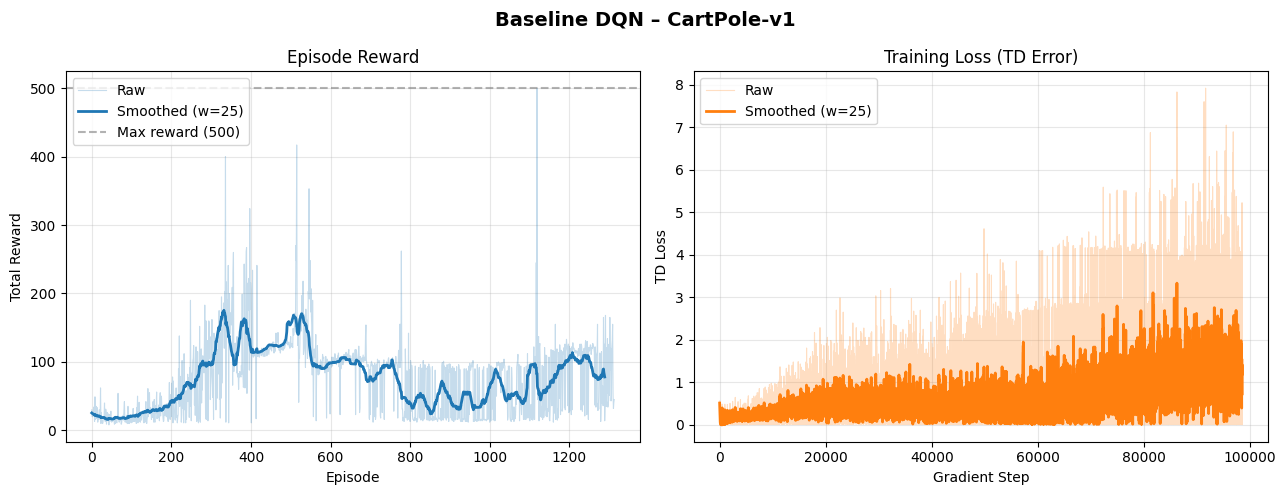

Saved: plot1_baseline_dqn.png


In [11]:
#Plot 1: Baseline DQN reward and loss curves

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Baseline DQN – CartPole-v1", fontsize=14, fontweight="bold")

# reward curve — raw is noisy so we overlay a smoothed version
r = cb_baseline.ep_rewards
axes[0].plot(r, alpha=0.25, color=COLORS[0], lw=0.8, label="Raw")
axes[0].plot(smooth(r), color=COLORS[0], lw=2, label="Smoothed (w=25)")
axes[0].axhline(500, ls="--", color="gray", alpha=0.6, label="Max reward (500)")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Total Reward")
axes[0].set_title("Episode Reward")
axes[0].legend()
axes[0].grid(alpha=0.3)

# TD loss — should trend downward as Q-values stabilise
ls = cb_baseline.losses
if ls:
    axes[1].plot(ls, alpha=0.25, color=COLORS[1], lw=0.8, label="Raw")
    axes[1].plot(smooth(ls), color=COLORS[1], lw=2, label="Smoothed (w=25)")
axes[1].set_xlabel("Gradient Step")
axes[1].set_ylabel("TD Loss")
axes[1].set_title("Training Loss (TD Error)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("plot1_baseline_dqn.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot1_baseline_dqn.png")

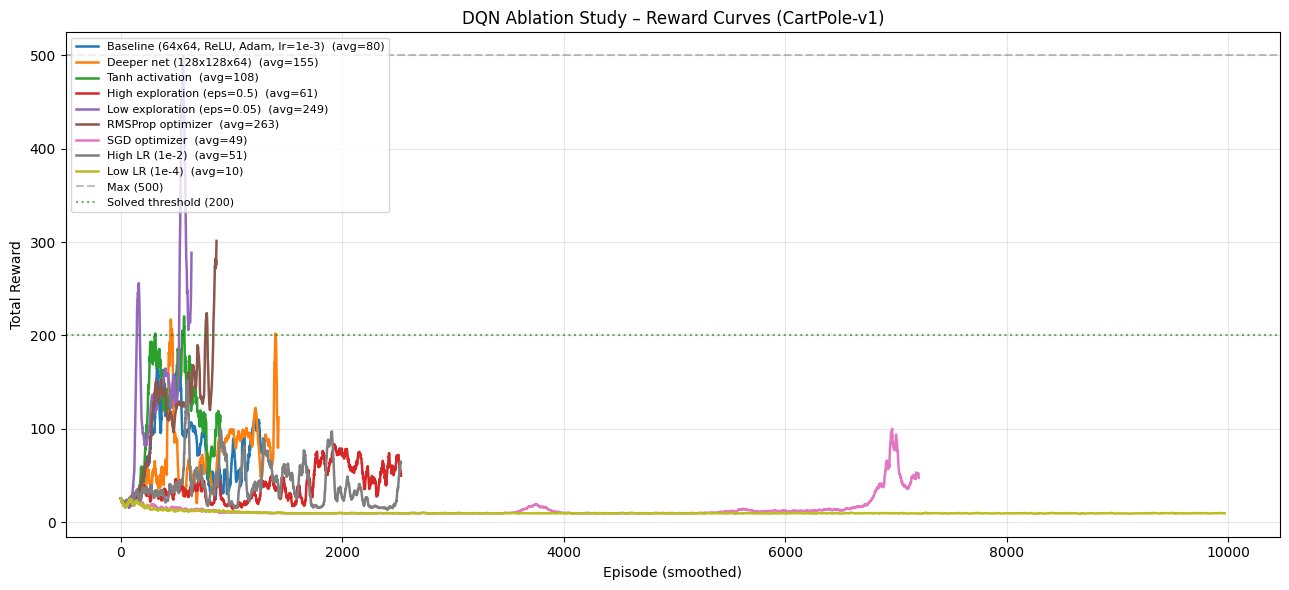

Saved: plot2_ablation_rewards.png


In [12]:
# Plot 2: Ablation reward curves (all configs)

fig, ax = plt.subplots(figsize=(13, 6))

for i, (name, res) in enumerate(ablation_results.items()):
    ax.plot(smooth(res["rewards"]), color=COLORS[i % 10], lw=1.8,
            label=f"{name}  (avg={res['avg50']:.0f})")

ax.axhline(500, ls="--", color="gray",  alpha=0.5, label="Max (500)")
ax.axhline(200, ls=":",  color="green", alpha=0.6, label="Solved threshold (200)")
ax.set_xlabel("Episode (smoothed)")
ax.set_ylabel("Total Reward")
ax.set_title("DQN Ablation Study – Reward Curves (CartPole-v1)")
ax.legend(fontsize=8, loc="upper left")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("plot2_ablation_rewards.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot2_ablation_rewards.png")

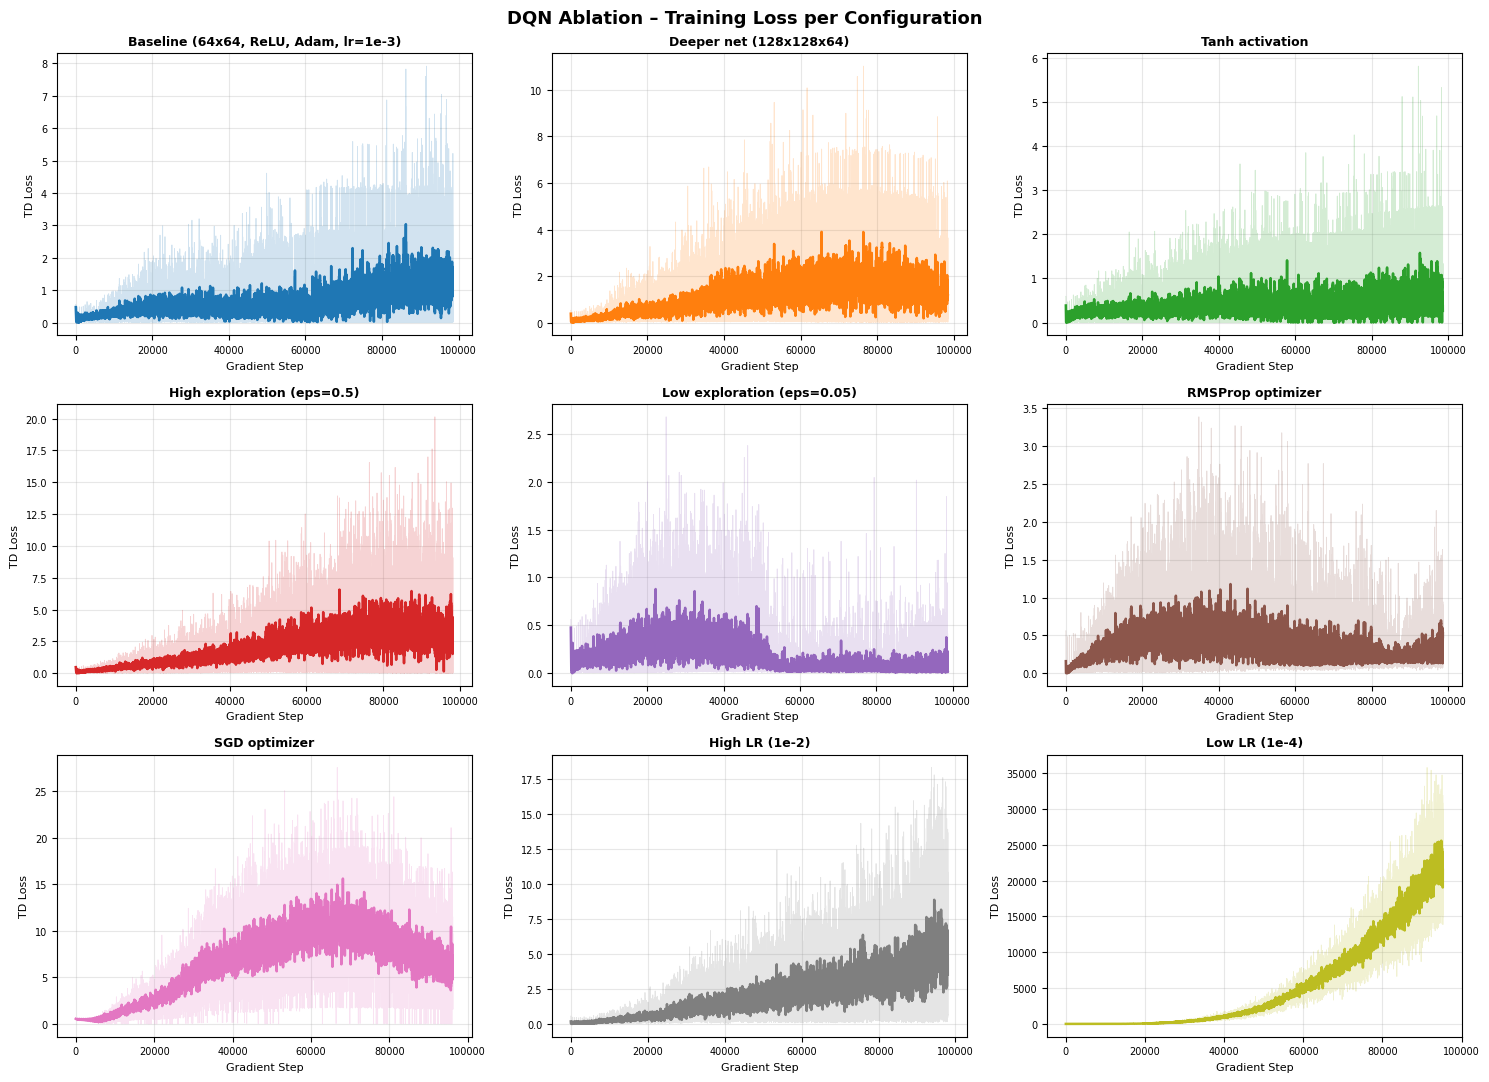

Saved: plot3_ablation_losses.png


In [13]:
# Plot 3: Ablation loss curves (3x3 grid)

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for i, (name, res) in enumerate(ablation_results.items()):
    ls = res["losses"]
    if ls:
        axes[i].plot(ls, alpha=0.2, color=COLORS[i % 10], lw=0.6)
        axes[i].plot(smooth(ls, 40), color=COLORS[i % 10], lw=1.8)
    axes[i].set_title(name, fontsize=9, fontweight="bold")
    axes[i].set_xlabel("Gradient Step", fontsize=8)
    axes[i].set_ylabel("TD Loss", fontsize=8)
    axes[i].grid(alpha=0.3)
    axes[i].tick_params(labelsize=7)

fig.suptitle("DQN Ablation – Training Loss per Configuration",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("plot3_ablation_losses.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot3_ablation_losses.png")

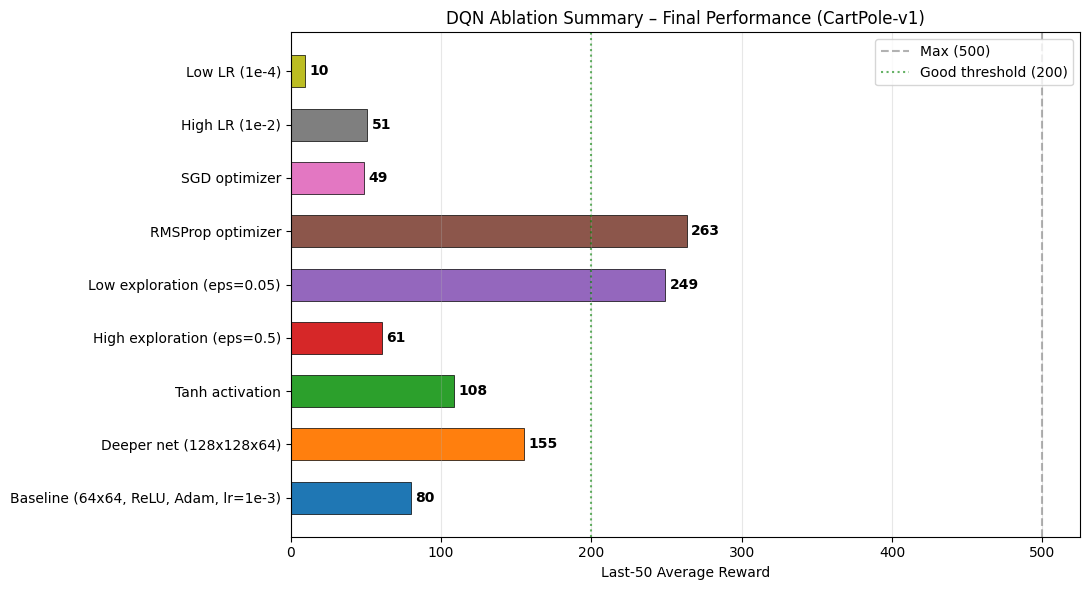

Saved: plot4_ablation_bar.png


In [14]:
#Plot 4: Ablation bar chart (final performance)

fig, ax = plt.subplots(figsize=(11, 6))

names  = list(ablation_results.keys())
scores = [ablation_results[n]["avg50"] for n in names]

bars = ax.barh(
    names, scores,
    color     = [COLORS[i % 10] for i in range(len(names))],
    edgecolor = "black",
    linewidth = 0.5,
    height    = 0.6,
)

ax.axvline(500, ls="--", color="gray",  alpha=0.6, label="Max (500)")
ax.axvline(200, ls=":",  color="green", alpha=0.6, label="Good threshold (200)")

# label each bar with its score
for bar, s in zip(bars, scores):
    ax.text(bar.get_width() + 3,
            bar.get_y() + bar.get_height() / 2,
            f"{s:.0f}", va="center", fontsize=10, fontweight="bold")

ax.set_xlabel("Last-50 Average Reward")
ax.set_title("DQN Ablation Summary – Final Performance (CartPole-v1)")
ax.legend()
ax.grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig("plot4_ablation_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot4_ablation_bar.png")

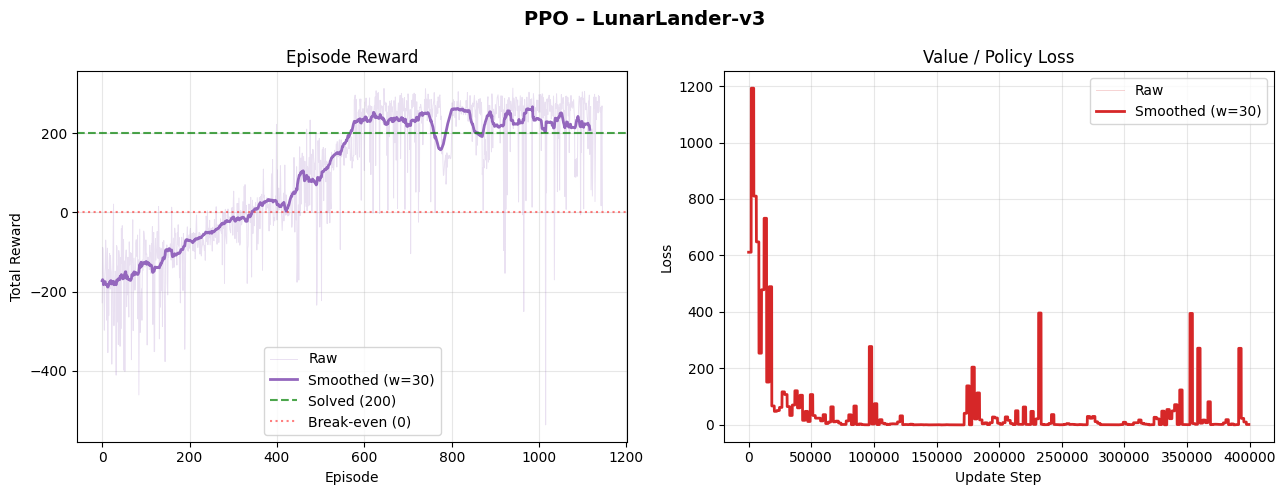

Saved: plot5_ppo_lunarlander.png


In [15]:
#Plot 5: PPO LunarLander reward and loss curves

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("PPO – LunarLander-v3", fontsize=14, fontweight="bold")

r = cb_ppo.ep_rewards
axes[0].plot(r, alpha=0.2, color=COLORS[4], lw=0.7, label="Raw")
axes[0].plot(smooth(r, 30), color=COLORS[4], lw=2, label="Smoothed (w=30)")
axes[0].axhline(200, ls="--", color="green", alpha=0.7, label="Solved (200)")
axes[0].axhline(0,   ls=":",  color="red",   alpha=0.5, label="Break-even (0)")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Total Reward")
axes[0].set_title("Episode Reward")
axes[0].legend()
axes[0].grid(alpha=0.3)

ls = cb_ppo.losses
if ls:
    axes[1].plot(ls, alpha=0.2, color=COLORS[3], lw=0.7, label="Raw")
    axes[1].plot(smooth(ls, 30), color=COLORS[3], lw=2, label="Smoothed (w=30)")
axes[1].set_xlabel("Update Step")
axes[1].set_ylabel("Loss")
axes[1].set_title("Value / Policy Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("plot5_ppo_lunarlander.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot5_ppo_lunarlander.png")

In [17]:
#Final results summary and analysis

print("FINAL RESULTS SUMMARY")

print(f"\nBaseline DQN (CartPole-v1) : {np.mean(cb_baseline.ep_rewards[-50:]):.1f}")
print(f"PPO (LunarLander) : {np.mean(cb_ppo.ep_rewards[-50:]):.1f} (solved >= 200)\n")

print("Ablation results ranked best to worst:")

sorted_ablation = sorted(ablation_results.items(), key=lambda x: -x[1]["avg50"])

for rank, (name, res) in enumerate(sorted_ablation, 1):
    print(f"  {rank}. {name:<42s} {res['avg50']:>6.1f}")

FINAL RESULTS SUMMARY

Baseline DQN (CartPole-v1) : 79.7
PPO (LunarLander) : 225.7 (solved >= 200)

Ablation results ranked best to worst:
  1. RMSProp optimizer                           263.3
  2. Low exploration (eps=0.05)                  249.2
  3. Deeper net (128x128x64)                     155.1
  4. Tanh activation                             108.4
  5. Baseline (64x64, ReLU, Adam, lr=1e-3)        79.7
  6. High exploration (eps=0.5)                   60.7
  7. High LR (1e-2)                               51.0
  8. SGD optimizer                                48.6
  9. Low LR (1e-4)                                 9.5
